# Gabarito: Desafio GaussPay
**Curso:** Tratamento de Dados na Prática com Python  
**Organização:** Gauss Jr.  

Este notebook contém a solução oficial para a limpeza da base `usuarios_gausspay_bruto_longo.csv`. O código foi adaptado da nossa aula principal para resolver os novos desafios desta base de 1000 linhas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# 1. Leitura da Base de Dados
# (Certifique-se de que rodou o gerador ou fez upload do CSV para o Colab)
df = pd.read_csv('/content/usuarios_gausspay_bruto.csv')

print("Tamanho original:", df.shape)
df.head()

Tamanho original: (1000, 6)


,id_usuario,idade_anos,sexo,salario_mensal,data_adesao,risco_fraude
0,1,56,Feminino,NaN,10-10-2023,0.46
1,2,62,Masc,13972,28-09-2023,0.33
2,3,999,masc,"13.928,50",2023-03-25,0.95
3,4,quarenta,M,5910,NaN,NaN
4,5,44,Masculino,5.8k,2023-05-28,0.07


In [ ]:
# =================================================================
# 2. TRATAMENTO DOS DADOS (As Adaptações)
# =================================================================

# A. IDADE: Novos textos e limites lógicos
mapa_idades = {
    "dezoito": 18,
    "vinte e um": 21,
    "trinta e dois": 32,
    "quarenta": 40,
    "cinquenta": 50
}
df["idade_anos"] = df["idade_anos"].replace(mapa_idades)
df["idade_num"] = pd.to_numeric(df["idade_anos"], errors="coerce")
df.loc[(df["idade_num"] < 18) | (df["idade_num"] > 100), "idade_num"] = np.nan
df["idade_final"] = df["idade_num"].astype('Int64')

# B. SEXO: Padronização imediata (Igual ao 'Gênero')
df["sexo_limpo"] = df["sexo"].astype(str).str.strip().str.upper().str[0]

# C. SALÁRIO: A nossa super Regex com Lookahead
df["salario_limpo"] = (
    df["salario_mensal"]
    .astype(str)
    .str.lower()
    .str.replace("k", "000", regex=False)
    .str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)  # Remove ponto de milhar
    .str.replace(",", ".", regex=False)                 # Vírgula decimal vira ponto
)
df["salario_limpo"] = pd.to_numeric(df["salario_limpo"], errors="coerce")

# D. DATA DE ADESÃO: Ajuste de traços para barras e conversão datetime
df["data_adesao"] = df["data_adesao"].astype(str).str.strip().str.replace("-", "/")
df["data_limpa"] = pd.to_datetime(
    df["data_adesao"],
    format='mixed',
    dayfirst=True,
    errors="coerce"
)

In [ ]:
# =================================================================
# 3. IMPUTAÇÃO E FAXINA FINAL (Remoção do Alvo Nulo e Seleção)
# =================================================================

# --- [OPCIONAL] TRATAMENTO DE NULOS POR IMPUTAÇÃO ---
# Se quiséssemos preencher os buracos nas variáveis de entrada (features)
# em vez de perder os clientes, usaríamos a Mediana (robusta a outliers):
# df["idade_final"] = df["idade_final"].fillna(df["idade_final"].median())
# df["salario_limpo"] = df["salario_limpo"].fillna(df["salario_limpo"].median())

# Como 'risco_fraude' é o nosso alvo (target) do modelo de ML,
# a regra de ouro diz que NÃO podemos imputá-lo para não inventar o que queremos prever.
# Portanto, removemos sumariamente as linhas onde ele for nulo.
df_limpo = df.dropna(subset=["risco_fraude"]).copy()

# Seleção segura das colunas limpas
colunas_finais = ["id_usuario", "idade_final", "sexo_limpo", "salario_limpo", "data_limpa", "risco_fraude"]
df_final = df_limpo[colunas_finais].copy()

# Renomeando para a entrega final (nomes limpos e elegantes)
df_final.columns = ["id", "idade", "sexo", "salario", "data_adesao", "risco_fraude"]

# Formatando a data visualmente para padrão brasileiro (opcional, mas elegante)
df_final['data_adesao'] = df_final['data_adesao'].dt.strftime('%d/%m/%Y')

print("Tamanho final após limpeza e remoção de nulos no alvo:", df_final.shape)
df_final.to_csv("/content/usuarios_gausspay_tratado.csv", index=False)
print("\n✓ Base exportada com sucesso!")

df_final.head(10)

Tamanho final após limpeza e remoção de nulos no alvo: (896, 6)

✓ Base exportada com sucesso!


,id,idade,sexo,salario,data_adesao,risco_fraude
0,1,56,F,NaN,10/10/2023,0.46
1,2,62,M,13972.0,28/09/2023,0.33
2,3,<NA>,M,13928.5,25/03/2023,0.95
4,5,44,M,5.8,28/05/2023,0.07
5,6,49,M,21000.0,23/03/2023,0.19
6,7,27,F,11000.0,05/12/2023,0.82
7,8,46,M,NaN,27/04/2023,0.12
8,9,35,M,37000.0,NaN,0.25
9,10,73,M,4326.5,NaN,0.44
10,11,49,F,19631.5,19/11/2023,0.03


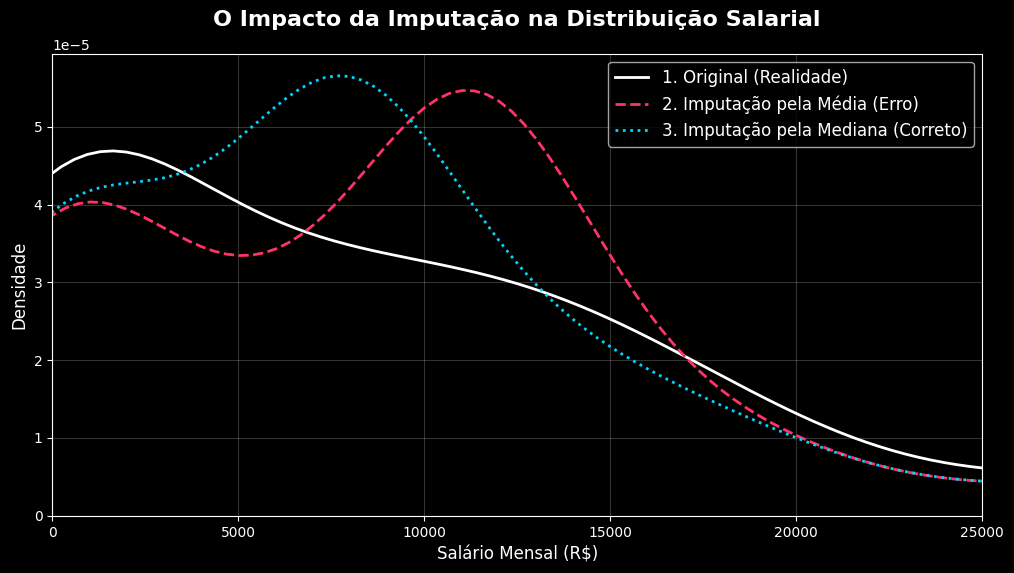

In [ ]:
# =================================================================
# BLOCO EXTRA: IMPUTAÇÃO (MÉDIA vs MEDIANA)
# =================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a estética visual do gráfico (Dark Mode com Azul)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6))

# 1. O Dado Original (Removendo os NaNs apenas para ver a curva real)
sns.kdeplot(df_final['salario'].dropna(),
            color='white', linewidth=2, label='1. Original (Realidade)', ax=ax)

# 2. A Ilusão da Média (O que acontece se preenchermos os NaNs com a Média)
salario_media = df_final['salario'].fillna(df_final['salario'].mean())
sns.kdeplot(salario_media,
            color='#ff3366', linewidth=2, linestyle='--', label='2. Imputação pela Média (Erro)', ax=ax)

# 3. A Robustez da Mediana (A Abordagem Segura)
salario_mediana = df_final['salario'].fillna(df_final['salario'].median())
sns.kdeplot(salario_mediana,
            color='#00d4ff', linewidth=2, linestyle=':', label='3. Imputação pela Mediana (Correto)', ax=ax)

# Ajustes do Gráfico
ax.set_title("O Impacto da Imputação na Distribuição Salarial", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Salário Mensal (R$)", fontsize=12)
ax.set_ylabel("Densidade", fontsize=12)
ax.legend(fontsize=12)
plt.xlim(0, 25000) # Focando onde a maioria dos dados está
plt.grid(alpha=0.2)

plt.show()